In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\전처리완료_카드(가맹점).csv", encoding='utf-8')
df

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,...,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt,mm_cnt_num
0,2023-01-01,41135,41135510,100470,Q13,음식,커피/음료,A,57,1,...,0,1,0,0,0,0,0,1,0,57
1,2023-01-01,41135,41135510,100470,R07,학문/교육,입시학원,A,84,1,...,0,1,0,0,0,0,0,0,1,84
2,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,A,1,1,...,1,0,1,0,0,1,0,0,0,1
3,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,E,32,1,...,0,0,1,0,0,1,0,0,0,32
4,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,신규,0,1,...,1,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2130066,2025-12-01,41135,41135670,99971,F02,생활서비스,미용서비스,A,6,1,...,0,1,0,1,0,0,0,0,0,6
2130067,2025-12-01,41135,41135670,99971,F06,생활서비스,세탁/가사서비스,A,199,1,...,0,0,0,0,0,0,0,0,1,199
2130068,2025-12-01,41135,41135670,99971,Q03,음식,닭/오리요리,A,166,1,...,0,0,0,0,0,0,0,0,1,166
2130069,2025-12-01,41135,41135670,99986,R03,학문/교육,기타교육,A,12,1,...,0,1,0,0,1,0,0,0,0,12


In [58]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 구명 매핑 (행정동 차트 가독성)
gu_map = {"41135": "분당구", "41133": "수정구", "41131": "중원구"}
df["구명"] = df["cty_rgn_no"].astype(str).map(gu_map)
df["구_행정동"] = df["구명"] + "_" + df["admi_cty_no"].astype(str)

# 매출구간 E 제외 (분석용)
df_eda = df[df["sale"] != "E"].copy()
df_eda["ta_ym"] = pd.to_datetime(df_eda["ta_ym"])

# 원도심(수정구,중원구) / 분당구 분리
df_원도심 = df_eda[df_eda["cty_rgn_no"].astype(str).isin(["41133", "41131"])].copy()
df_분당구 = df_eda[df_eda["cty_rgn_no"].astype(str) == "41135"].copy()

print(f"전체: {len(df):,}행  →  E 제외 후: {len(df_eda):,}행")
print(f"  원도심(수정+중원): {len(df_원도심):,}행")
print(f"  분당구(신도심):    {len(df_분당구):,}행")
print()
print("매출구간 분포 (E 제외):")
print(df_eda["sale"].value_counts())

전체: 2,130,071행  →  E 제외 후: 1,742,211행
  원도심(수정+중원): 898,306행
  분당구(신도심):    843,905행

매출구간 분포 (E 제외):
sale
A     1069467
B      231895
C      214109
D      159267
신규      67473
Name: count, dtype: int64


## 1. 개폐업률 

| 지표 | 공식 |
|---|---|
| 개업률 (%) | Σ open_cnt / Σ mer_cnt × 100 |
| 폐업률 (%) | Σ close_cnt / Σ mer_cnt × 100 |

- 집계 단위별로 수량을 **합산한 뒤** 비율을 계산한다 (비율의 평균이 아님)
-  (30억 초과 또는 국세청 미등록) 제외

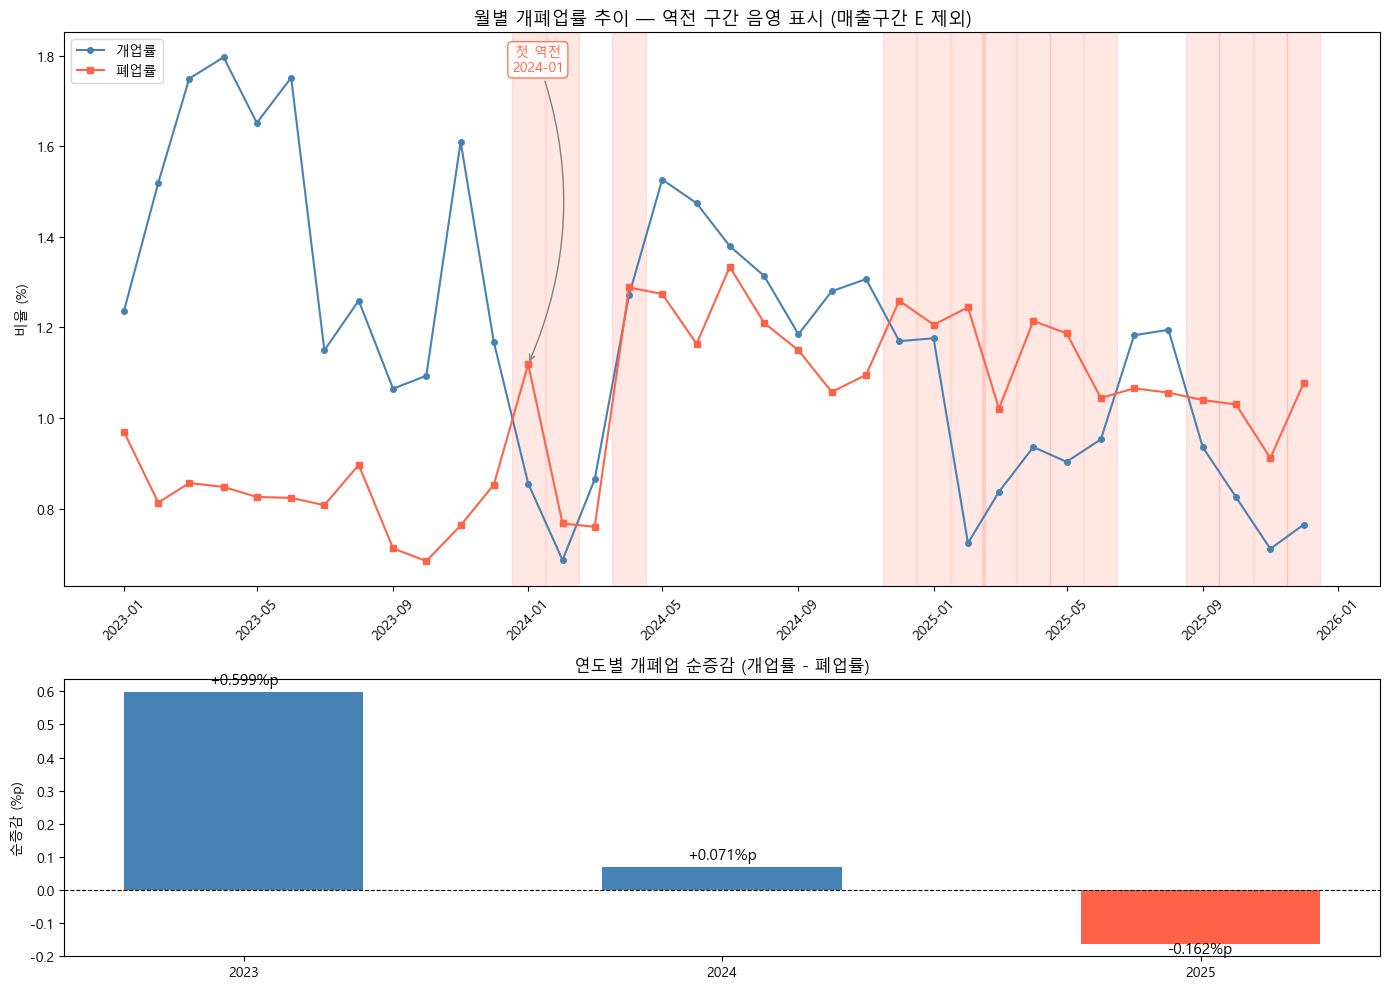

=== 연도별 개폐업률 요약 ===
         개업률    폐업률    순증감
ta_ym                     
2023   1.419  0.821  0.599
2024   1.195  1.124  0.071
2025   0.927  1.090 -0.162

역전 발생: 14개월 / 전체 36개월

=== 역전 구간 목록 (폐업률 > 개업률) ===
  ta_ym      개업률      폐업률       순증감
2024-01 0.855258 1.118608 -0.263349
2024-02 0.686163 0.767186 -0.081023
2024-04 1.270792 1.288183 -0.017391
2024-12 1.169549 1.259055 -0.089506
2025-01 1.176051 1.205779 -0.029728
2025-02 0.723858 1.244204 -0.520346
2025-03 0.837014 1.020501 -0.183486
2025-04 0.935880 1.214209 -0.278329
2025-05 0.903238 1.186947 -0.283709
2025-06 0.952744 1.044088 -0.091343
2025-09 0.935511 1.039578 -0.104067
2025-10 0.825229 1.029850 -0.204621
2025-11 0.711150 0.911616 -0.200466
2025-12 0.764287 1.076352 -0.312065


In [59]:
# ── 구조적 전환점 분석 ───────────────────────────────────────────
# 개업률 < 폐업률 역전 구간을 음영으로 표시하고, 연도별 순증감을 병행 시각화

monthly = (
    df_eda.groupby("ta_ym")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
monthly["개업률"] = monthly["open_cnt"] / monthly["mer_cnt"] * 100
monthly["폐업률"] = monthly["close_cnt"] / monthly["mer_cnt"] * 100

monthly["역전"] = monthly["폐업률"] > monthly["개업률"]
monthly["순증감"] = monthly["개업률"] - monthly["폐업률"]

# 연도별 집계
yearly = (
    df_eda.groupby(df_eda["ta_ym"].dt.year)[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
)
yearly["개업률"] = yearly["open_cnt"] / yearly["mer_cnt"] * 100
yearly["폐업률"] = yearly["close_cnt"] / yearly["mer_cnt"] * 100
yearly["순증감"] = yearly["개업률"] - yearly["폐업률"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1.5]})

# 상단: 월별 추이 + 역전 구간 음영 ────────────────────────────────────
ax = axes[0]
ax.plot(monthly["ta_ym"], monthly["개업률"], marker="o", ms=4, label="개업률", color="steelblue")
ax.plot(monthly["ta_ym"], monthly["폐업률"], marker="s", ms=4, label="폐업률", color="tomato")

for _, row in monthly[monthly["역전"]].iterrows():
    ax.axvspan(
        row["ta_ym"] - pd.Timedelta(days=15),
        row["ta_ym"] + pd.Timedelta(days=15),
        alpha=0.15, color="tomato",
    )

# 첫 역전 시점 주석 — 텍스트를 axes fraction(차트 상단)에 고정해 데이터와 겹침 방지
first_cross = monthly[monthly["역전"]].iloc[0]["ta_ym"]
y_arrow = monthly.loc[monthly["ta_ym"] == first_cross, "폐업률"].values[0]
ax.annotate(
    f"첫 역전\n{first_cross.strftime('%Y-%m')}",
    xy=(first_cross, y_arrow),
    xycoords="data",
    xytext=(0.36, 0.93),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="gray", connectionstyle="arc3,rad=-0.2"),
    fontsize=10, color="tomato", ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="tomato", alpha=0.85),
)

ax.set_title("월별 개폐업률 추이 — 역전 구간 음영 표시 (매출구간 E 제외)", fontsize=13)
ax.set_ylabel("비율 (%)")
ax.legend()
ax.tick_params(axis="x", rotation=45)

# 하단: 연도별 순증감 막대 ────────────────────────────────────────────
ax2 = axes[1]
bar_colors = ["steelblue" if v >= 0 else "tomato" for v in yearly["순증감"]]
bars = ax2.bar(yearly.index.astype(str), yearly["순증감"], color=bar_colors, width=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, v in zip(bars, yearly["순증감"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        v + (0.01 if v >= 0 else -0.04),
        f"{v:+.3f}%p",
        ha="center", va="bottom", fontsize=11,
    )
ax2.set_title("연도별 개폐업 순증감 (개업률 - 폐업률)", fontsize=12)
ax2.set_ylabel("순증감 (%p)")

plt.tight_layout()
plt.show()

# 수치 요약 출력
print("=== 연도별 개폐업률 요약 ===")
print(yearly[["개업률", "폐업률", "순증감"]].round(3).to_string())
print()
n_rev = monthly["역전"].sum()
print(f"역전 발생: {n_rev}개월 / 전체 {len(monthly)}개월")
print()
print("=== 역전 구간 목록 (폐업률 > 개업률) ===")
rev = monthly[monthly["역전"]][["ta_ym", "개업률", "폐업률", "순증감"]].copy()
rev["ta_ym"] = rev["ta_ym"].dt.strftime("%Y-%m")
print(rev.to_string(index=False))

# 그래프 해석

- 2024년 1월에 폐업률이 개업률을 역전한 첫번째 시점
- 전체 36개월중 14개월이 폐업률이 개업률을 상회하는 수치를 보임
- 2025년에는 12개월 중 10개월이 폐업률 우위로, 구조적 감소 국면에 진입함을 알 수 있음

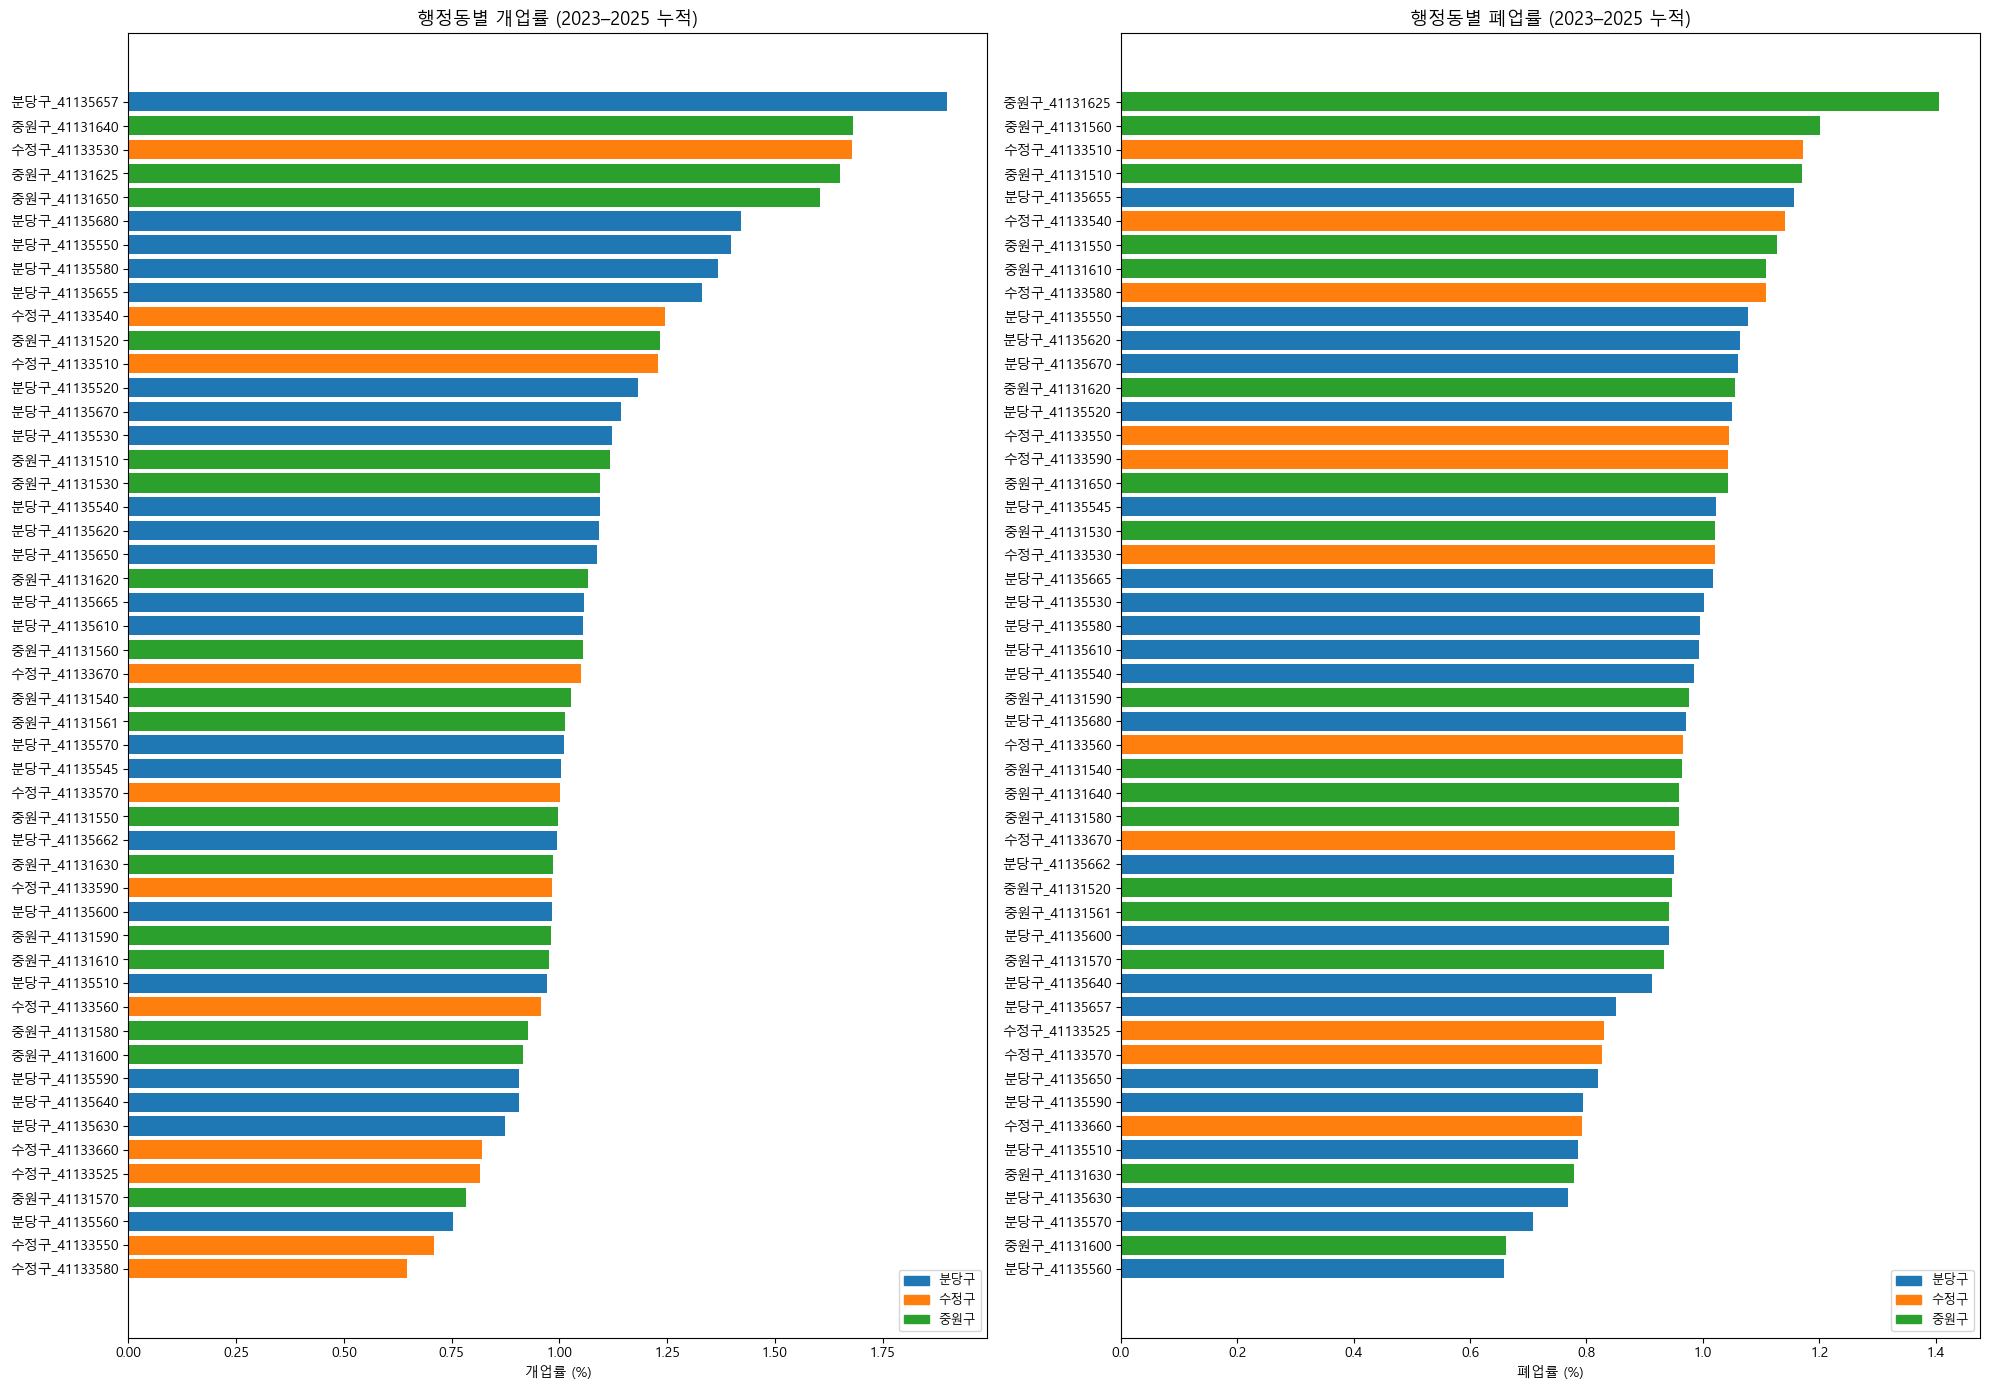

개업률 상위 5 행정동:
       구_행정동      개업률      폐업률
분당구_41135657 1.898202 0.850960
중원구_41131640 1.680176 0.959657
수정구_41133530 1.679766 1.020188
중원구_41131625 1.651286 1.405816
중원구_41131650 1.605207 1.042753

폐업률 상위 5 행정동:
       구_행정동      개업률      폐업률
중원구_41131625 1.651286 1.405816
중원구_41131560 1.054726 1.201493
수정구_41133510 1.228994 1.171784
중원구_41131510 1.116471 1.169637
분당구_41135655 1.331250 1.157052


In [60]:
# ── 행정동별 개폐업률 (전체 기간 합산) ────────────────────────────
dong = (
    df_eda.groupby("구_행정동")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
dong["개업률"] = dong["open_cnt"] / dong["mer_cnt"] * 100
dong["폐업률"] = dong["close_cnt"] / dong["mer_cnt"] * 100
dong["순증감"] = dong["개업률"] - dong["폐업률"]
dong["구명"]   = dong["구_행정동"].str.split("_").str[0]

# 구별 색상 구분
color_map = {label: c for label, c in zip(
    dong["구_행정동"].str.split("_").str[0].unique(),
    ["#1f77b4", "#ff7f0e", "#2ca02c"]
)}
bar_colors_open  = dong.sort_values("개업률", ascending=True)["구_행정동"].str.split("_").str[0].map(color_map)
bar_colors_close = dong.sort_values("폐업률", ascending=True)["구_행정동"].str.split("_").str[0].map(color_map)

dong_open  = dong.sort_values("개업률", ascending=True)
dong_close = dong.sort_values("폐업률", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

axes[0].barh(dong_open["구_행정동"], dong_open["개업률"], color=bar_colors_open.values)
axes[0].set_title("행정동별 개업률 (2023–2025 누적)", fontsize=13)
axes[0].set_xlabel("개업률 (%)")

axes[1].barh(dong_close["구_행정동"], dong_close["폐업률"], color=bar_colors_close.values)
axes[1].set_title("행정동별 폐업률 (2023–2025 누적)", fontsize=13)
axes[1].set_xlabel("폐업률 (%)")

# 범례
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=g) for g, c in color_map.items()]
axes[0].legend(handles=legend_patches, loc="lower right", fontsize=9)
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print("개업률 상위 5 행정동:")
print(dong.nlargest(5, "개업률")[["구_행정동", "개업률", "폐업률"]].to_string(index=False))
print()
print("폐업률 상위 5 행정동:")
print(dong.nlargest(5, "폐업률")[["구_행정동", "개업률", "폐업률"]].to_string(index=False))

## 젠트리피케이션 단계 분류 (개폐업률 기반)

개업률·폐업률을 **중앙값** 기준으로 4사분면에 배치해 단계를 분류합니다.

| 단계 | 개업률 | 폐업률 | 의미 |
|---|---|---|---|
| 안정 | 낮음 | 낮음 | 상권 안정 또는 점진적 공동화 |
| 초기 | 높음 | 낮음 | 외부 자본 유입, 신규 업종 진입 시작 |
| 진행 | 높음 | 높음 | 기존 상인 교체 중 — 상권 불안정 구간 |
| 위험 | 낮음 | 높음 | 신규 유입 고갈 + 기존 상인 이탈 동시 진행 |

In [61]:
# ── 젠트리피케이션 단계 분류 ─────────────────────────────────────────
# 중앙값 기준 4사분면: 개업률↑폐업률↓=초기 / 개업률↑폐업률↑=진행
#                    개업률↓폐업률↑=위험  / 개업률↓폐업률↓=안정

med_open  = dong["개업률"].median()
med_close = dong["폐업률"].median()
def classify_stage(row):
    hi_open  = row["개업률"] >= med_open
    hi_close = row["폐업률"] >= med_close
    if hi_open and not hi_close:
        return "초기"
    elif hi_open and hi_close:
        return "진행"
    elif not hi_open and hi_close:
        return "위험"
    else:
        return "안정"

dong["젠트리피케이션_단계"] = dong.apply(classify_stage, axis=1)

stage_colors = {
    "안정":       "#2ca02c",
    "초기":       "#1f77b4",
    "진행": "#ff7f0e",
    "위험":       "#d62728",
}
stage_order = ["안정", "초기", "진행", "위험"]

print(f"기준 중앙값 — 개업률: {med_open:.3f}%  /  폐업률: {med_close:.3f}%")
print()
print("=== 행정동별 젠트리피케이션 단계 분류 결과 ===")
print(
    dong[["구_행정동", "개업률", "폐업률", "순증감", "젠트리피케이션_단계"]]
    .sort_values(["젠트리피케이션_단계", "순증감"])
    .round(3)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 (전체) ===")
print(dong["젠트리피케이션_단계"].value_counts()[stage_order].to_string())

# 원도심 위험·진행 단계 별도 출력
dong_원도심_stage = dong[dong["구명"].isin(["수정구", "중원구"])].copy()
print()
print("=== 원도심(수정+중원) 위험/진행 단계 행정동 ===")
risk_dong = dong_원도심_stage[
    dong_원도심_stage["젠트리피케이션_단계"].isin(["위험", "진행"])
]
print(
    risk_dong[["구_행정동", "개업률", "폐업률", "순증감", "젠트리피케이션_단계"]]
    .sort_values(["젠트리피케이션_단계", "순증감"])
    .round(3)
    .to_string(index=False)
)

기준 중앙값 — 개업률: 1.039%  /  폐업률: 0.981%

=== 행정동별 젠트리피케이션 단계 분류 결과 ===
       구_행정동   개업률   폐업률    순증감 젠트리피케이션_단계
중원구_41131570 0.784 0.933 -0.149         안정
중원구_41131580 0.927 0.959 -0.032         안정
수정구_41133525 0.817 0.831 -0.014         안정
수정구_41133560 0.956 0.965 -0.009         안정
분당구_41135640 0.906 0.913 -0.007         안정
중원구_41131590 0.980 0.976  0.003         안정
수정구_41133660 0.820 0.793  0.027         안정
분당구_41135600 0.983 0.942  0.041         안정
분당구_41135662 0.995 0.951  0.044         안정
중원구_41131540 1.028 0.965  0.063         안정
중원구_41131561 1.013 0.943  0.070         안정
분당구_41135560 0.753 0.658  0.095         안정
분당구_41135630 0.874 0.768  0.106         안정
분당구_41135590 0.907 0.794  0.113         안정
수정구_41133570 1.002 0.827  0.175         안정
분당구_41135510 0.972 0.785  0.187         안정
중원구_41131630 0.986 0.778  0.208         안정
중원구_41131600 0.916 0.661  0.255         안정
분당구_41135570 1.012 0.708  0.304         안정
수정구_41133580 0.648 1.108 -0.460         위험
수정구_41133550 0.709 1.045 -0.3

C:\Users\rmstn\AppData\Local\Temp\ipykernel_19784\3885312579.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


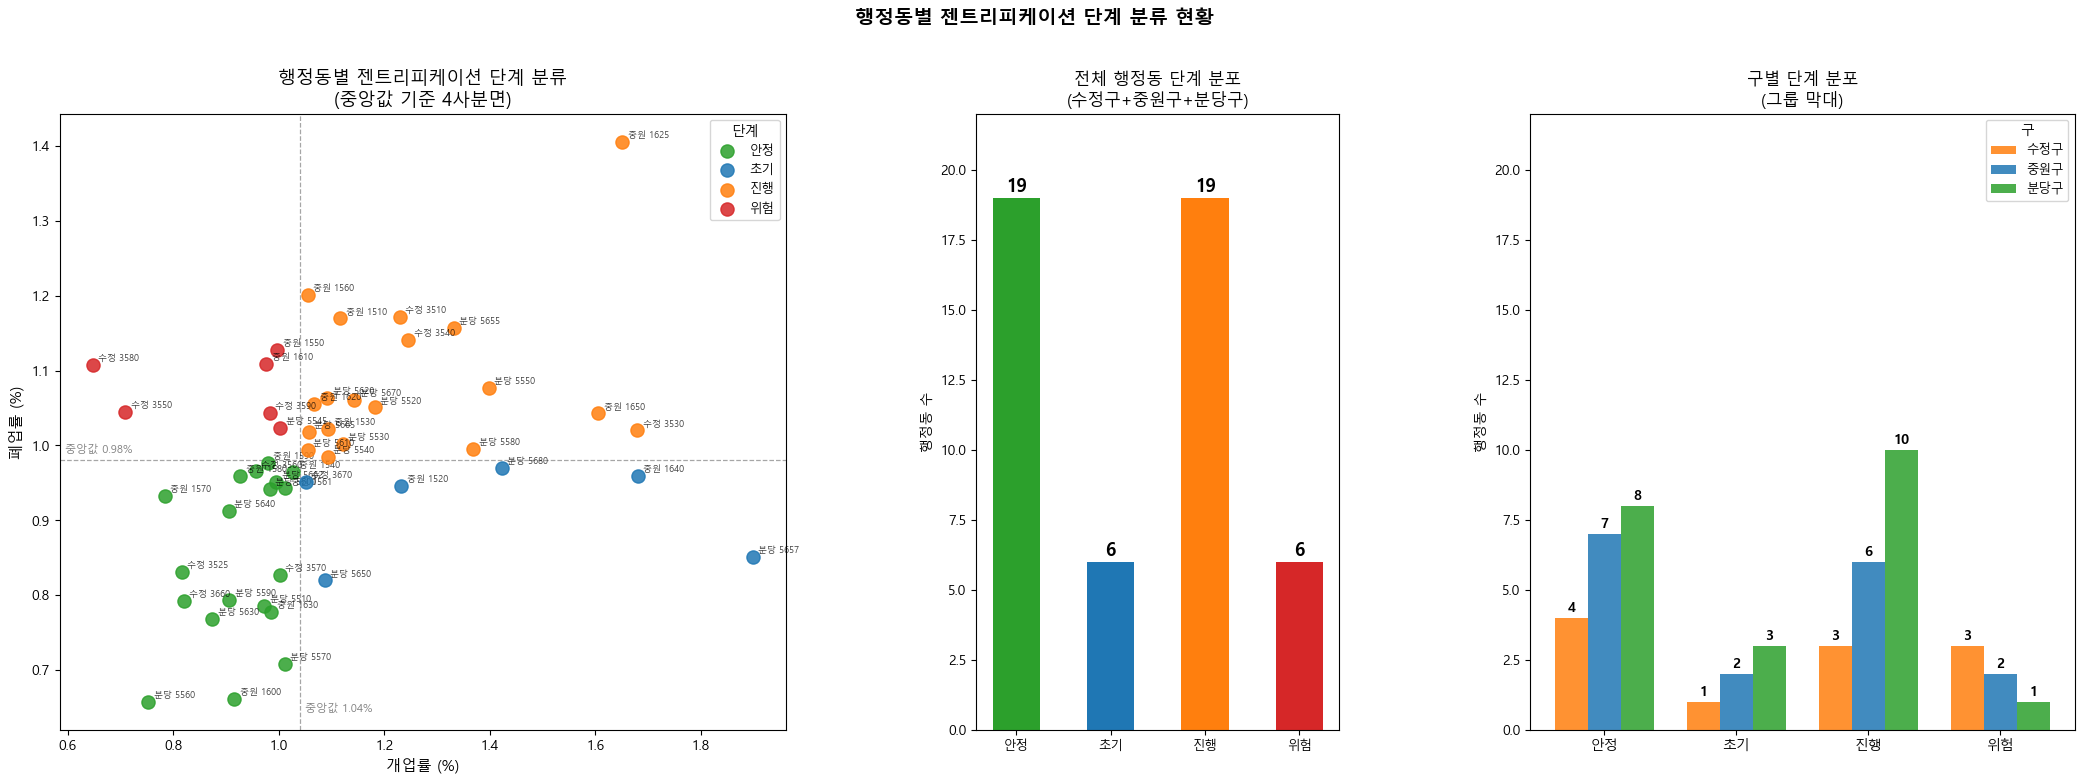

In [62]:
# ── 시각화 ───────────────────────────────────────────────────────────
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(26, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_scatter = fig.add_subplot(gs[0])
ax_total   = fig.add_subplot(gs[1])
ax_gu      = fig.add_subplot(gs[2])

# ── 왼쪽: 개업률 vs 폐업률 산점도 ────────────────────────────────────
for stage in stage_order:
    grp = dong[dong["젠트리피케이션_단계"] == stage]
    ax_scatter.scatter(grp["개업률"], grp["폐업률"],
                       label=stage, color=stage_colors[stage], s=90, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        short = row["구_행정동"].split("_")[0][:2] + " " + row["구_행정동"].split("_")[1][-4:]
        ax_scatter.annotate(short, (row["개업률"], row["폐업률"]),
                            fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_scatter.axvline(med_open,  color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_scatter.axhline(med_close, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_scatter.text(med_open + 0.01, ax_scatter.get_ylim()[0] + 0.02,
                f"중앙값 {med_open:.2f}%", fontsize=8, color="gray", va="bottom")
ax_scatter.text(ax_scatter.get_xlim()[0] + 0.01, med_close + 0.01,
                f"중앙값 {med_close:.2f}%", fontsize=8, color="gray")
ax_scatter.set_xlabel("개업률 (%)", fontsize=11)
ax_scatter.set_ylabel("폐업률 (%)", fontsize=11)
ax_scatter.set_title("행정동별 젠트리피케이션 단계 분류\n(중앙값 기준 4사분면)", fontsize=13)
ax_scatter.legend(title="단계", fontsize=9)

# ── 중간: 전체 행정동 단계 분포 ──────────────────────────────────────
counts_total = [dong["젠트리피케이션_단계"].value_counts().get(s, 0) for s in stage_order]
bars = ax_total.bar(stage_order, counts_total,
                    color=[stage_colors[s] for s in stage_order], width=0.5)
for bar, v in zip(bars, counts_total):
    ax_total.text(bar.get_x() + bar.get_width() / 2, v + 0.08, str(v),
                  ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_total.set_ylim(0, max(counts_total) + 3)
ax_total.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_total.set_ylabel("행정동 수")
ax_total.tick_params(axis="x", labelsize=9)

# ── 오른쪽: 구별 단계 분포 (그룹 막대) ───────────────────────────────
gu_list = ["수정구", "중원구", "분당구"]
gu_colors = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}

x = np.arange(len(stage_order))
width = 0.25

for i, gu in enumerate(gu_list):
    counts_gu = [
        dong[(dong["구명"] == gu) & (dong["젠트리피케이션_단계"] == s)].shape[0]
        for s in stage_order
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_colors[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")

ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order, fontsize=10)
ax_gu.set_title("구별 단계 분포\n(그룹 막대)", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_total) + 3)

plt.suptitle("행정동별 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 그래프 해석

- 위험(개업률은 낮고, 폐업률은 높음)에 해당하는 6개의 행정동 중 5개가 원도심에 해당됨
- 원도심 28개 행정동 중 14개가 위험 혹은 진행 단계임
- 분당구도 진행 단계인 행정동이 10개가 관측됨. 하지만 안정 단계도 그만큼 많은 상황

---

# 2. 프랜차이즈수 변화

## 행정동별 분기별 프랜차이즈 침투율

- 집계: 분기별 `fran_cnt` / `mer_cnt` × 100
- 상위 5개 기준: **전체 기간(2023 Q1 ~ 2025 Q4) 평균 침투율**
  - 단일 분기 이상치에 흔들리지 않고 구조적으로 프랜차이즈 비중이 높은 지역을 선별
  - 최신 분기(2025 Q4) 기준으로 뽑으면 일시적 급등 지역이 포함될 수 있어 평균이 더 안정적

In [63]:
# ── 분기별 프랜차이즈 침투율 계산 ────────────────────────────────────

df_eda["quarter"] = df_eda["ta_ym"].dt.quarter
df_eda["year"]    = df_eda["ta_ym"].dt.year
df_eda["분기"]    = df_eda["year"].astype(str) + "-Q" + df_eda["quarter"].astype(str)

# 행정동 + 분기별 집계
q_agg = (
    df_eda.groupby(["구_행정동", "구명", "분기"])[["fran_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
q_agg["침투율"] = q_agg["fran_cnt"] / q_agg["mer_cnt"] * 100

# 분기 순서 정렬용 키
quarter_order = sorted(q_agg["분기"].unique())
q_agg["분기"] = pd.Categorical(q_agg["분기"], categories=quarter_order, ordered=True)
q_agg = q_agg.sort_values(["구_행정동", "분기"])

# 피벗 테이블 형태로 출력 (행=행정동, 열=분기)
pivot_q = q_agg.pivot_table(index=["구_행정동", "구명"], columns="분기", values="침투율")
pivot_q.columns = [str(c) for c in pivot_q.columns]
pivot_q = pivot_q.round(2)

# 전체 기간 평균 침투율 컬럼 추가 (상위 기준)
pivot_q["평균침투율"] = pivot_q.mean(axis=1).round(2)
pivot_q = pivot_q.sort_values("평균침투율", ascending=False)

print(f"행정동 수: {len(pivot_q)}개  /  분기 수: {len(quarter_order)}개")
print()
display(pivot_q.head())


행정동 수: 50개  /  분기 수: 12개



,,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,평균침투율
구_행정동,구명,,,,,,,,,,,,,
중원구_41131640,중원구,7.94,8.17,8.24,8.75,9.09,8.61,7.26,7.35,6.51,6.75,6.17,6.32,7.60
중원구_41131625,중원구,7.61,7.88,7.76,7.79,7.79,8.09,7.34,7.29,6.46,6.67,6.10,6.07,7.24
분당구_41135655,분당구,6.69,6.77,7.11,7.34,7.62,7.86,7.11,7.29,6.74,6.89,6.21,6.46,7.01
분당구_41135540,분당구,6.70,6.98,6.94,6.99,7.15,7.21,6.78,6.99,6.44,6.72,6.45,6.33,6.81
분당구_41135560,분당구,6.12,6.44,6.79,7.35,7.22,7.17,6.37,7.13,6.75,6.82,6.59,6.42,6.76


상위 5개 행정동 (전체 기간 평균 침투율 기준):
                  평균침투율
구_행정동        구명        
중원구_41131640 중원구   7.60
중원구_41131625 중원구   7.24
분당구_41135655 분당구   7.01
분당구_41135540 분당구   6.81
분당구_41135560 분당구   6.76



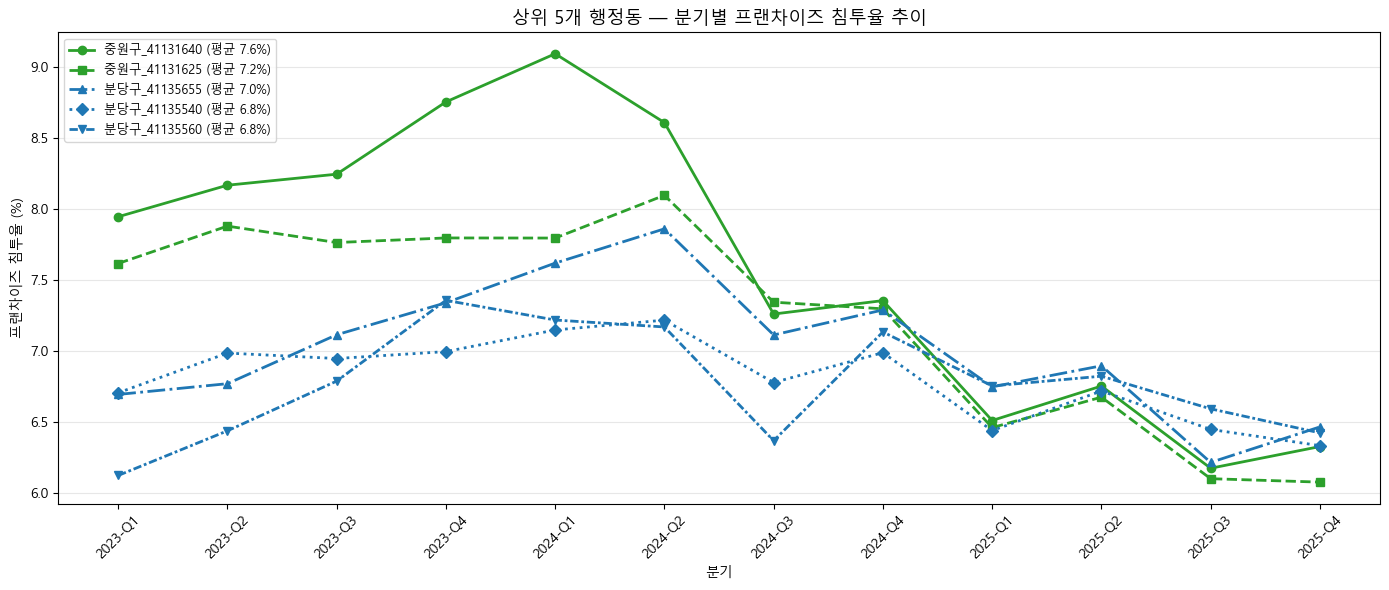

In [64]:
# ── 상위 5개 행정동 분기별 침투율 라인 차트 ─────────────────────────

top5 = pivot_q.nlargest(5, "평균침투율").index.get_level_values("구_행정동").tolist()
top5_data = q_agg[q_agg["구_행정동"].isin(top5)].copy()

print("상위 5개 행정동 (전체 기간 평균 침투율 기준):")
print(pivot_q.loc[pivot_q.index.get_level_values("구_행정동").isin(top5), ["평균침투율"]].to_string())
print()

gu_colors_fran = {"분당구": "#1f77b4", "수정구": "#ff7f0e", "중원구": "#2ca02c"}
markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, dong in enumerate(top5):
    grp = top5_data[top5_data["구_행정동"] == dong].sort_values("분기")
    gu = grp["구명"].iloc[0]
    avg = pivot_q.loc[pivot_q.index.get_level_values("구_행정동") == dong, "평균침투율"].values[0]
    label = f"{dong} (평균 {avg:.1f}%)"
    ax.plot(
        grp["분기"].astype(str), grp["침투율"],
        marker=markers[i], linewidth=2, markersize=6,
        color=gu_colors_fran[gu], label=label,
        linestyle=["-","--","-.",":",(0,(3,1,1,1))][i]
    )

ax.set_title("상위 5개 행정동 — 분기별 프랜차이즈 침투율 추이", fontsize=13)
ax.set_xlabel("분기")
ax.set_ylabel("프랜차이즈 침투율 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


##  프랜차이즈 침투율 기반 젠트리피케이션 단계 분류

| 단계 | 평균 침투율 | 분기 기울기 | 의미 |
|---|---|---|---|
| 안정 | 낮음 | 낮음 | 프랜차이즈 영향 없음, 상권 구조 유지 |
| 초기 | 낮음 | 높음 | 프랜차이즈 막 진입 시작 |
| 진행 | 높음 | 높음 | 프랜차이즈가 소상공인을 빠르게 대체 중 |
| 위험 | 높음 | 낮음 | 이미 포화 — 소상공인 대부분 이탈 완료 |

In [65]:
# 분기별 침투율 기울기 계산
from scipy.stats import linregress

def quarterly_slope(grp):
    grp = grp.sort_values("분기")
    x = list(range(len(grp)))
    slope, *_ = linregress(x, grp["침투율"].tolist())
    return slope

slope_q = (
    q_agg.groupby("구_행정동")
    .apply(quarterly_slope)
    .reset_index()
    .rename(columns={0: "기울기"})
)

fran_q_stage = (
    pivot_q[["평균침투율"]]
    .reset_index()
    .merge(slope_q, on="구_행정동")
)

med_rate  = fran_q_stage["평균침투율"].median()
med_slope = fran_q_stage["기울기"].median()

def classify(row):
    hi_r = row["평균침투율"] >= med_rate
    hi_s = row["기울기"]     >= med_slope
    if not hi_r and hi_s: return "초기"
    if hi_r and hi_s:     return "진행"
    if hi_r and not hi_s: return "위험"
    return "안정"

fran_q_stage["단계"] = fran_q_stage.apply(classify, axis=1)

stage_colors = {"안정":"#2ca02c","초기":"#1f77b4","진행":"#ff7f0e","위험":"#d62728"}
stage_order  = ["안정", "초기", "진행", "위험"]

print(f"기준 중앙값 — 평균 침투율: {med_rate:.2f}%  /  분기 기울기: {med_slope:.4f}")
print()
print("=== 행정동별 단계 분류 결과 ===")
print(
    fran_q_stage[["구_행정동", "구명", "평균침투율", "기울기", "단계"]]
    .sort_values(["단계", "평균침투율"], ascending=[True, False])
    .round(4)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 ===")
print(fran_q_stage["단계"].value_counts()[stage_order])


기준 중앙값 — 평균 침투율: 5.21%  /  분기 기울기: -0.0180

=== 행정동별 단계 분류 결과 ===
       구_행정동  구명  평균침투율     기울기 단계
분당구_41135610 분당구   5.01 -0.0227 안정
수정구_41133590 수정구   5.00 -0.0506 안정
분당구_41135545 분당구   4.80 -0.0235 안정
분당구_41135640 분당구   4.68 -0.0190 안정
분당구_41135590 분당구   4.39 -0.0815 안정
중원구_41131580 중원구   4.34 -0.0595 안정
중원구_41131550 중원구   4.11 -0.0359 안정
수정구_41133510 수정구   4.03 -0.0371 안정
분당구_41135630 분당구   3.89 -0.0399 안정
중원구_41131570 중원구   2.84 -0.0607 안정
중원구_41131640 중원구   7.60 -0.2237 위험
중원구_41131625 중원구   7.24 -0.1731 위험
분당구_41135655 분당구   7.01 -0.0480 위험
분당구_41135540 분당구   6.81 -0.0498 위험
중원구_41131610 중원구   6.21 -0.0311 위험
분당구_41135650 분당구   6.15 -0.1047 위험
분당구_41135520 분당구   5.81 -0.1524 위험
수정구_41133540 수정구   5.79 -0.0718 위험
분당구_41135670 분당구   5.72 -0.0614 위험
분당구_41135570 분당구   5.70 -0.0737 위험
중원구_41131540 중원구   5.55 -0.0851 위험
분당구_41135580 분당구   5.55 -0.0589 위험
중원구_41131510 중원구   5.27 -0.0292 위험
분당구_41135550 분당구   5.21 -0.0251 위험
분당구_41135657 분당구   5.21 -0.0260 위험
분당구_41135560 분당구   6.76 

C:\Users\rmstn\AppData\Local\Temp\ipykernel_19784\3917548939.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


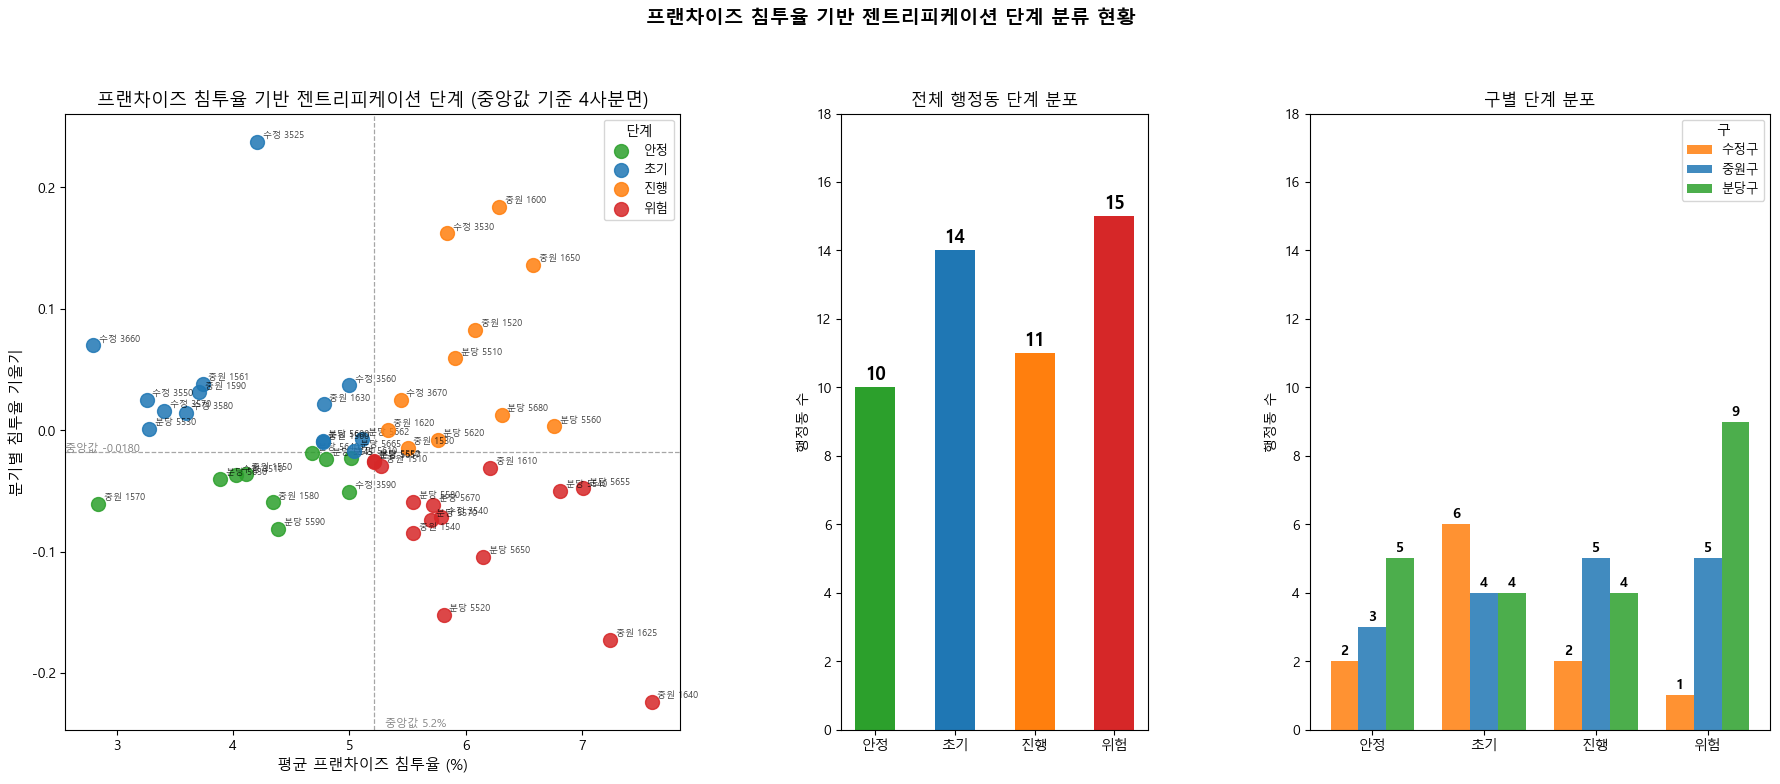

In [66]:
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(22, 8))
gs  = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_sc  = fig.add_subplot(gs[0])
ax_tot = fig.add_subplot(gs[1])
ax_gu  = fig.add_subplot(gs[2])

for stage in stage_order:
    grp = fran_q_stage[fran_q_stage["단계"] == stage]
    ax_sc.scatter(grp["평균침투율"], grp["기울기"],
                  label=stage, color=stage_colors[stage], s=100, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        short = row["구_행정동"].split("_")[0][:2] + " " + row["구_행정동"].split("_")[1][-4:]
        ax_sc.annotate(short, (row["평균침투율"], row["기울기"]),
                       fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_sc.axvline(med_rate,  color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.axhline(med_slope, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.text(med_rate + 0.1, ax_sc.get_ylim()[0],
           f"중앙값 {med_rate:.1f}%", fontsize=8, color="gray", va="bottom")
ax_sc.text(ax_sc.get_xlim()[0], med_slope + 0.0002,
           f"중앙값 {med_slope:.4f}", fontsize=8, color="gray")
ax_sc.set_xlabel("평균 프랜차이즈 침투율 (%)", fontsize=11)
ax_sc.set_ylabel("분기별 침투율 기울기", fontsize=11)
ax_sc.set_title("프랜차이즈 침투율 기반 젠트리피케이션 단계 (중앙값 기준 4사분면)", fontsize=13)
ax_sc.legend(title="단계", fontsize=9)

counts_total = [fran_q_stage["단계"].value_counts().get(s, 0) for s in stage_order]
bars = ax_tot.bar(stage_order, counts_total,
                  color=[stage_colors[s] for s in stage_order], width=0.5)
for bar, v in zip(bars, counts_total):
    ax_tot.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v),
                ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_tot.set_ylim(0, max(counts_total) + 3)
ax_tot.set_title("전체 행정동 단계 분포", fontsize=12)
ax_tot.set_ylabel("행정동 수")

gu_list    = ["수정구", "중원구", "분당구"]
gu_palette = {"수정구":"#ff7f0e","중원구":"#1f77b4","분당구":"#2ca02c"}
x = np.arange(len(stage_order))
width = 0.25
for i, gu in enumerate(gu_list):
    counts_gu = [
        fran_q_stage[(fran_q_stage["구명"] == gu) & (fran_q_stage["단계"] == s)].shape[0]
        for s in stage_order
    ]
    bars_gu = ax_gu.bar(x + (i-1)*width, counts_gu,
                        width=width, label=gu, color=gu_palette[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order, fontsize=10)
ax_gu.set_title("구별 단계 분포", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_total) + 3)

plt.suptitle("프랜차이즈 침투율 기반 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# 해석

- 프랜차이즈 침투율 분기별 추이와 단계별 분류 현황을 살펴보았을 때 가장 많은 행정동이 위험 단계에 속함
- 이는 프렌차이즈 침투가 정점을 찍고 내려오는 구간으로, 상권 자체가 수축 중임을 의미
- 분당구는 위험 단계에 속하는 행정동이 가장 많음 이는 이미 구조적 포화임을 의미함
- 수정구에 해당하는 행정동은 아직 안정, 초기에 분포해 있는 단계

---

# 3. 업종 다양성

## 분석 방법론: 섀넌 다양성 지수 (Shannon Entropy)

| 지표 | 공식 |
|---|---|
| 다양성 지수 H | H = −Σ (p_i × ln p_i) |
| p_i | 해당 소분류 업종의 가맹점 수 / 전체 가맹점 수 |

- 집계 기준: **소분류 업종(`card_tpbuz_nm_2`)** — 대분류는 너무 거칠고, 소분류로 실제 업종 쏠림을 포착
- H값이 높을수록 업종이 고르게 분포 (다양), 낮을수록 특정 업종 집중 (단순)
- **안정성 필터**: 행정동 × 분기별 가맹점 합계 50개 미만 조합 제외
- 논문에서도 사용되는 지수 : https://kpaj.or.kr/_PR/view/?aidx=44988&bidx=4067

In [67]:
# ── 섀넌 다양성 지수 계산 (소분류 기준, 행정동 × 분기) ───────────────
from scipy.stats import entropy as scipy_entropy

# 행정동 + 분기 + 소분류별 가맹점 수 집계
div_agg = (
    df_eda.groupby(["구_행정동", "구명", "분기", "card_tpbuz_nm_2"])["mer_cnt"]
    .sum()
    .reset_index()
)

# 안정성 필터: 행정동 × 분기 합계 50개 이상만 유지
valid_pairs = (
    df_eda.groupby(["구_행정동", "분기"])["mer_cnt"]
    .sum()
    .reset_index()
    .query("mer_cnt >= 50")[["구_행정동", "분기"]]
)
div_agg = div_agg.merge(valid_pairs, on=["구_행정동", "분기"])

# 섀넌 엔트로피 (자연로그 기준)
def shannon_h(group):
    counts = group["mer_cnt"].values
    total  = counts.sum()
    if total == 0:
        return np.nan
    return scipy_entropy(counts / total, base=np.e)

div_h = (
    div_agg.groupby(["구_행정동", "구명", "분기"])
    .apply(shannon_h)
    .reset_index()
    .rename(columns={0: "다양성지수"})
)

div_h["분기"] = pd.Categorical(div_h["분기"], categories=quarter_order, ordered=True)
div_h = div_h.sort_values(["구_행정동", "분기"])

print(f"유효 행정동 × 분기 조합: {len(div_h):,}개")
print()
print("=== 다양성 지수 요약 통계 ===")
print(div_h["다양성지수"].describe().round(4))

유효 행정동 × 분기 조합: 600개

=== 다양성 지수 요약 통계 ===
count    600.0000
mean       3.5644
std        0.1079
min        3.1913
25%        3.5181
50%        3.5815
75%        3.6376
max        3.8078
Name: 다양성지수, dtype: float64


다양성 하위 5개 행정동 (전체 기간 평균 기준):
       구_행정동  구명  평균다양성
중원구_41131630 중원구 3.2535
중원구_41131570 중원구 3.3180
분당구_41135530 분당구 3.3285
수정구_41133550 수정구 3.3365
중원구_41131640 중원구 3.4020


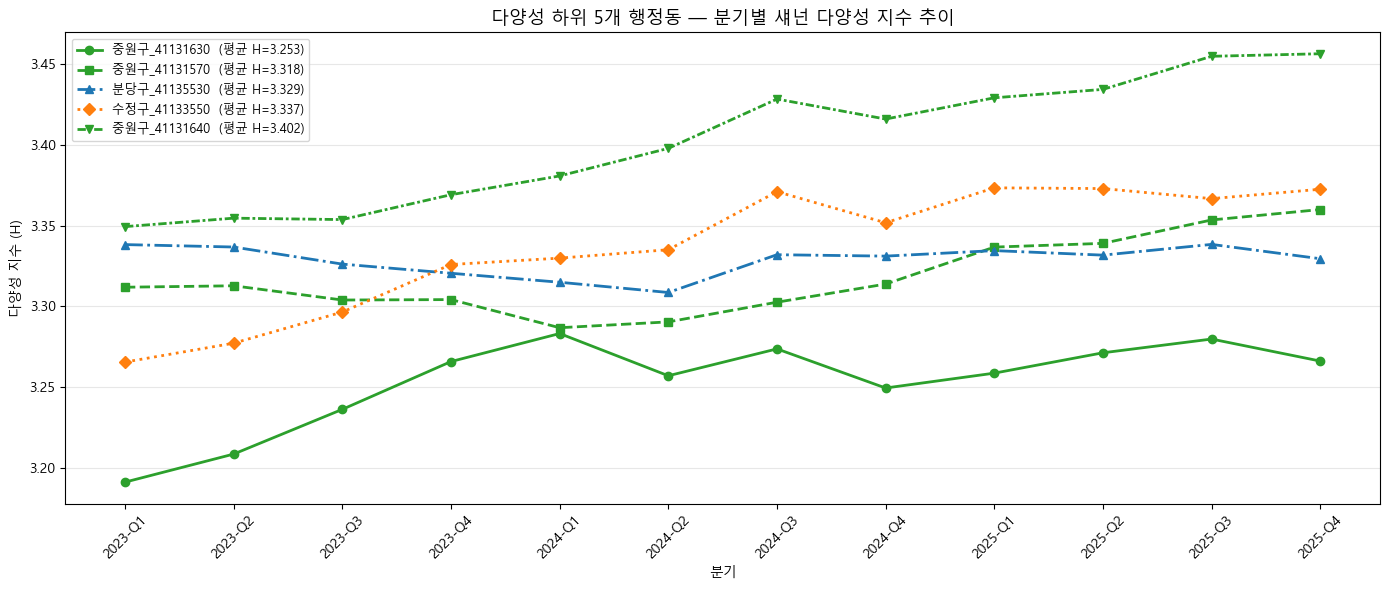

In [68]:
# ── 다양성 하위 5개 행정동 분기별 추이 라인 차트 ─────────────────────
dong_avg = (
    div_h.groupby(["구_행정동", "구명"])["다양성지수"]
    .mean()
    .reset_index()
    .rename(columns={"다양성지수": "평균다양성"})
    .sort_values("평균다양성")
)

bottom5 = dong_avg.head(5)["구_행정동"].tolist()
bottom5_data = div_h[div_h["구_행정동"].isin(bottom5)].copy()

print("다양성 하위 5개 행정동 (전체 기간 평균 기준):")
print(dong_avg.head(5)[["구_행정동", "구명", "평균다양성"]].round(4).to_string(index=False))

gu_colors_div2 = {"분당구": "#1f77b4", "수정구": "#ff7f0e", "중원구": "#2ca02c"}
markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, dong_name in enumerate(bottom5):
    grp = bottom5_data[bottom5_data["구_행정동"] == dong_name].sort_values("분기")
    gu  = grp["구명"].iloc[0]
    avg = dong_avg.loc[dong_avg["구_행정동"] == dong_name, "평균다양성"].values[0]
    ax.plot(
        grp["분기"].astype(str), grp["다양성지수"],
        marker=markers[i], linewidth=2, markersize=6,
        color=gu_colors_div2[gu],
        label=f"{dong_name}  (평균 H={avg:.3f})",
        linestyle=["-", "--", "-.", ":", (0, (3, 1, 1, 1))][i],
    )

ax.set_title("다양성 하위 5개 행정동 — 분기별 섀넌 다양성 지수 추이", fontsize=13)
ax.set_xlabel("분기")
ax.set_ylabel("다양성 지수 (H)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 업종 다양성 기반 젠트리피케이션 단계 분류

### 분류 기준 (중앙값 기준 4사분면)

| 축 | 기준값 | 의미 |
|---|---|---|
| 평균 다양성 (H) | 전체 행정동 중앙값 | 업종이 구조적으로 다양한지 여부 |
| 분기 기울기 | 전체 행정동 중앙값 | 다양성이 증가 추세인지 감소 추세인지 |

> 실제 중앙값은 아래 셀 실행 시 출력됩니다.

### 단계별 정의 및 젠트리피케이션 연관성

| 단계 | 평균 H | 기울기 | 상권 상태 | 젠트리피케이션 국면 |
|---|---|---|---|---|
| 안정 | 높음 | 양수 | 다양한 업종이 더 늘어나는 건강한 상권 | 젠트리피케이션 이전 또는 저항 단계 |
| 초기 | 낮음 | 양수 | 단순한 상권이지만 소폭 회복 중 | 젠트리피케이션 초기 진입 또는 재편 단계 |
| 진행 | 높음 | 음수 | 원래 다양했지만 특정 업종으로 쏠리기 시작 | **젠트리피케이션 진행 신호** — 기존 다양성이 무너지는 중 |
| 위험 | 낮음 | 음수 | 이미 단순하고 더 단순해지는 중 | **공동화 위험** — 소상공인 이탈 후 대체 업종도 없는 상태 |

### 젠트리피케이션과의 연결고리
- 젠트리피케이션이 진행되면 임대료 상승으로 소규모·다양한 업종이 퇴출되고 자본력 있는 특정 업종(카페, 프랜차이즈 음식점 등)이 집중됩니다.
- **진행** 단계 지역은 개폐업률의 "진행" 단계, 프랜차이즈 침투율의 "진행" 단계와 겹칠 경우 젠트리피케이션이 가장 강하게 작동하고 있는 구간으로 해석할 수 있습니다.
- **위험** 단계 지역은 이미 교체가 완료된 후 수요 자체가 소멸한 공동화 단계로, 정책적 개입이 가장 시급한 구간입니다.

In [69]:
# ── 행정동별 평균 다양성 + 분기 기울기 계산 → 4단계 분류 ─────────────
from scipy.stats import linregress

pivot_div = div_h.pivot_table(index=["구_행정동", "구명"], columns="분기", values="다양성지수")
pivot_div.columns = [str(c) for c in pivot_div.columns]
pivot_div["평균다양성"] = pivot_div.mean(axis=1).round(4)

def calc_slope_div(grp):
    grp = grp.dropna(subset=["다양성지수"]).sort_values("분기")
    if len(grp) < 3:
        return np.nan
    x = list(range(len(grp)))
    slope, *_ = linregress(x, grp["다양성지수"].tolist())
    return slope

slope_div = (
    div_h.groupby("구_행정동")
    .apply(calc_slope_div)
    .reset_index()
    .rename(columns={0: "기울기"})
)

div_summary = (
    pivot_div[["평균다양성"]]
    .reset_index()
    .merge(slope_div, on="구_행정동")
)

# 중앙값 기준 4사분면 분류
med_h_val  = div_summary["평균다양성"].median()
med_s_val  = div_summary["기울기"].median()

def classify_div(row):
    hi_h = row["평균다양성"] >= med_h_val
    hi_s = row["기울기"]     >= med_s_val
    if   hi_h and hi_s:     return "안정"
    elif hi_h and not hi_s: return "진행"
    elif not hi_h and hi_s: return "초기"
    else:                   return "위험"

div_summary["단계"] = div_summary.apply(classify_div, axis=1)

stage_colors_div = {
    "안정": "#2ca02c",
    "초기": "#1f77b4",
    "진행": "#ff7f0e",
    "위험": "#d62728",
}
stage_order_div = ["안정", "초기", "진행", "위험"]

print(f"기준 중앙값 — 평균 다양성: {med_h_val:.4f}  /  기울기: {med_s_val:.6f}")
print()
print("=== 행정동별 업종 다양성 단계 분류 ===")
print(
    div_summary[["구_행정동", "구명", "평균다양성", "기울기", "단계"]]
    .sort_values(["단계", "평균다양성"], ascending=[True, False])
    .round(4)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 ===")
print(div_summary["단계"].value_counts()[stage_order_div].to_string())

기준 중앙값 — 평균 다양성: 3.5783  /  기울기: 0.000975

=== 행정동별 업종 다양성 단계 분류 ===
       구_행정동  구명  평균다양성     기울기 단계
분당구_41135630 분당구 3.7201  0.0023 안정
분당구_41135640 분당구 3.6846  0.0027 안정
중원구_41131520 중원구 3.6607  0.0066 안정
중원구_41131600 중원구 3.6434  0.0091 안정
수정구_41133530 수정구 3.6403  0.0053 안정
중원구_41131550 중원구 3.6376  0.0013 안정
수정구_41133560 수정구 3.5928  0.0016 안정
분당구_41135610 분당구 3.5835  0.0010 안정
수정구_41133580 수정구 3.5765 -0.0061 위험
중원구_41131530 중원구 3.5573 -0.0037 위험
중원구_41131610 중원구 3.5409  0.0003 위험
분당구_41135657 분당구 3.5340  0.0009 위험
수정구_41133570 수정구 3.4935  0.0009 위험
중원구_41131510 중원구 3.4879 -0.0016 위험
중원구_41131650 중원구 3.4850 -0.0019 위험
분당구_41135530 분당구 3.3285  0.0003 위험
중원구_41131580 중원구 3.7748 -0.0031 진행
분당구_41135670 분당구 3.7147 -0.0019 진행
분당구_41135662 분당구 3.6681  0.0004 진행
분당구_41135600 분당구 3.6666 -0.0013 진행
수정구_41133540 수정구 3.6576 -0.0018 진행
분당구_41135620 분당구 3.6492 -0.0042 진행
분당구_41135520 분당구 3.6471 -0.0005 진행
수정구_41133670 수정구 3.6414 -0.0025 진행
중원구_41131625 중원구 3.6391 -0.0022 진행
분당구_41135580 분당구 3.63

C:\Users\rmstn\AppData\Local\Temp\ipykernel_19784\31521080.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


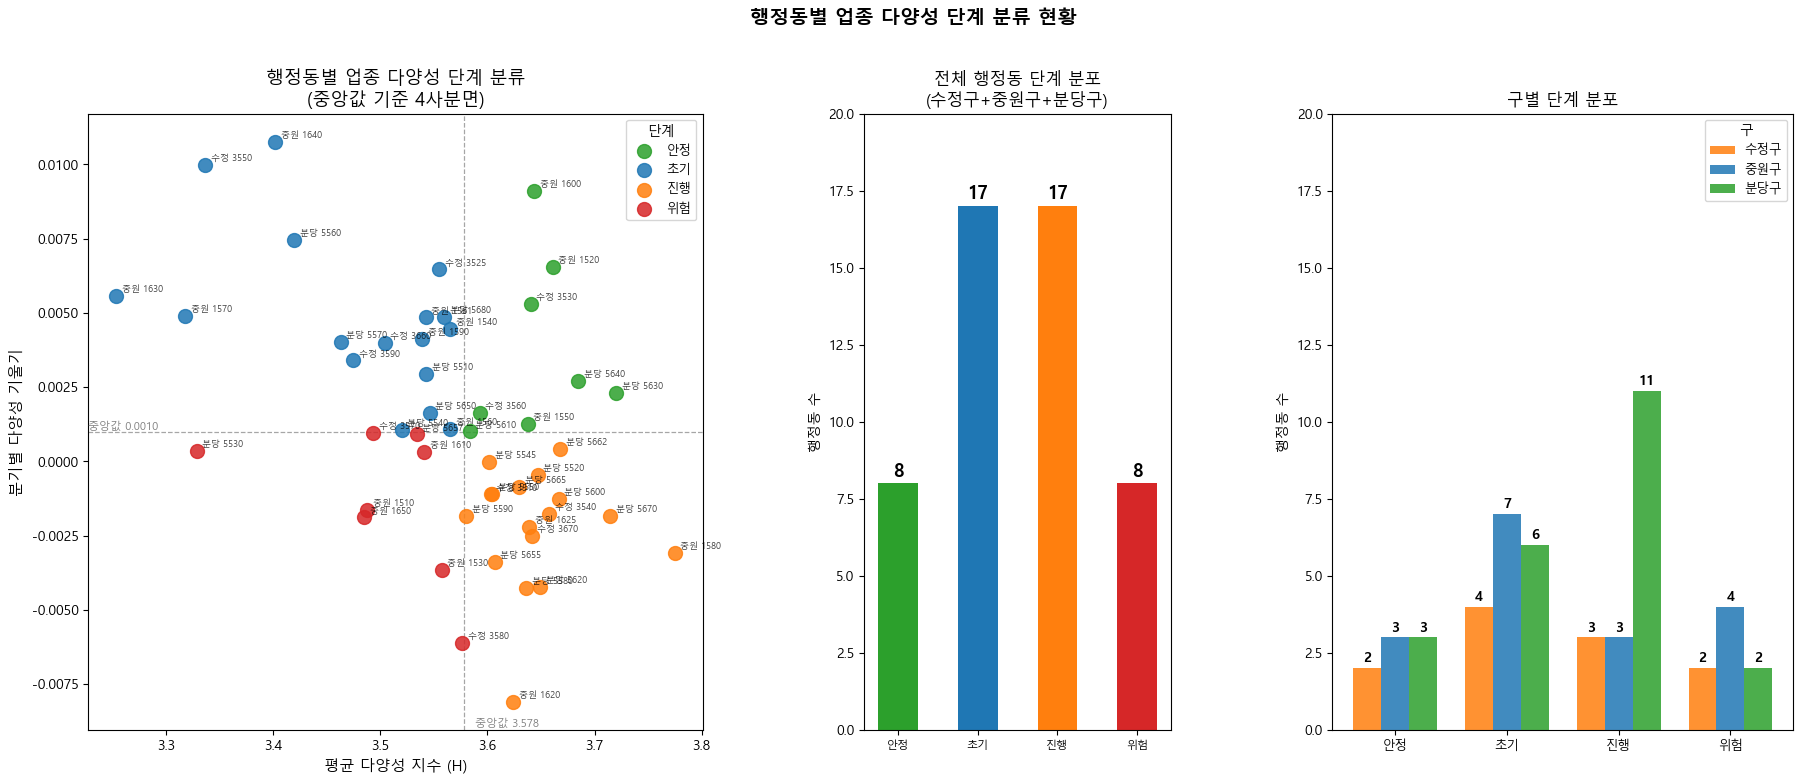

In [70]:
# ── 시각화: 산점도 + 전체 분포 + 구별 분포 ────────────────────────────
from matplotlib.patches import Patch

fig = plt.figure(figsize=(22, 8))
gs  = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_sc  = fig.add_subplot(gs[0])
ax_tot = fig.add_subplot(gs[1])
ax_gu  = fig.add_subplot(gs[2])

# 왼쪽: 평균 다양성 vs 기울기 산점도
for stage in stage_order_div:
    grp = div_summary[div_summary["단계"] == stage]
    ax_sc.scatter(grp["평균다양성"], grp["기울기"],
                  label=stage, color=stage_colors_div[stage], s=100, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        short = row["구_행정동"].split("_")[0][:2] + " " + row["구_행정동"].split("_")[1][-4:]
        ax_sc.annotate(short, (row["평균다양성"], row["기울기"]),
                       fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_sc.axvline(med_h_val, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.axhline(med_s_val, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.text(med_h_val + 0.01, ax_sc.get_ylim()[0],
           f"중앙값 {med_h_val:.3f}", fontsize=8, color="gray", va="bottom")
ax_sc.text(ax_sc.get_xlim()[0], med_s_val + 0.0001,
           f"중앙값 {med_s_val:.4f}", fontsize=8, color="gray")
ax_sc.set_xlabel("평균 다양성 지수 (H)", fontsize=11)
ax_sc.set_ylabel("분기별 다양성 기울기", fontsize=11)
ax_sc.set_title("행정동별 업종 다양성 단계 분류\n(중앙값 기준 4사분면)", fontsize=13)
ax_sc.legend(title="단계", fontsize=9)

# 중간: 전체 분포
counts_div = [div_summary["단계"].value_counts().get(s, 0) for s in stage_order_div]
bars = ax_tot.bar(stage_order_div, counts_div,
                  color=[stage_colors_div[s] for s in stage_order_div], width=0.5)
for bar, v in zip(bars, counts_div):
    ax_tot.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_tot.set_ylim(0, max(counts_div) + 3)
ax_tot.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_tot.set_ylabel("행정동 수")
ax_tot.tick_params(axis="x", labelsize=8)

# 오른쪽: 구별 분포
gu_list    = ["수정구", "중원구", "분당구"]
gu_palette = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}
x = np.arange(len(stage_order_div))
width = 0.25
for i, gu in enumerate(gu_list):
    counts_gu = [
        div_summary[(div_summary["구명"] == gu) & (div_summary["단계"] == s)].shape[0]
        for s in stage_order_div
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_palette[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order_div, fontsize=9)
ax_gu.set_title("구별 단계 분포", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_div) + 3)

plt.suptitle("행정동별 업종 다양성 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

분석 대상 행정동: 25개 (진행 + 위험)

▲ 비중 증가 업종 Top 10:
                 2023-Q1  2025-Q4    변화
card_tpbuz_nm_2                        
한식                 10.67    11.52  0.85
별식/퓨전요리             0.76     1.35  0.59
커피/음료               4.50     4.96  0.46
인터넷쇼핑               1.57     1.96  0.39
일반스포츠               1.78     2.15  0.37
미용서비스               5.56     5.84  0.28
의복/의류               7.19     7.38  0.19
취미/오락               1.39     1.54  0.15
요가/단전/마사지           0.90     1.02  0.12
입시학원                2.37     2.47  0.10

▼ 비중 감소 업종 Top 10:
                 2023-Q1  2025-Q4    변화
card_tpbuz_nm_2                        
인테리어/가정용품           2.99     2.59 -0.40
제조/도매               3.05     2.74 -0.31
가전제품                1.93     1.63 -0.30
교통서비스               1.16     0.86 -0.30
일반병원                2.21     1.94 -0.27
차량관리/서비스            2.20     1.93 -0.27
음/식료품소매             3.03     2.77 -0.26
특화병원                1.30     1.07 -0.23
유아교육                1.21     1.05 -0.16
의약/의료품         

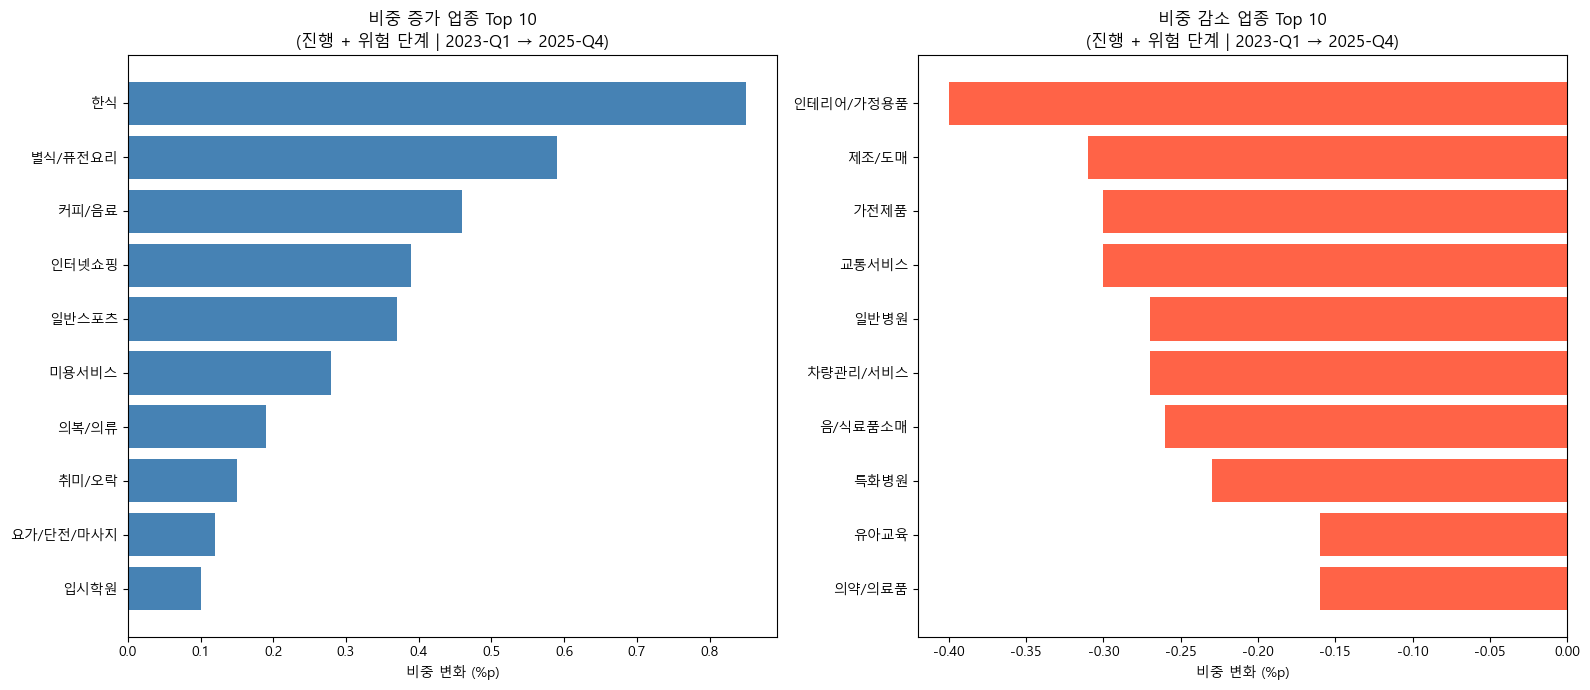

In [71]:
# ── 다양성 감소 지역 업종 교체 분석 ──────────────────────────────────
# "진행" + "위험" 단계 지역에서 2023-Q1 → 2025-Q4 업종 비중 변화

declining_dong = div_summary[div_summary["단계"].isin(["진행", "위험"])]["구_행정동"].tolist()

df_23q1 = df_eda[(df_eda["분기"] == "2023-Q1") & (df_eda["구_행정동"].isin(declining_dong))]
df_25q4 = df_eda[(df_eda["분기"] == "2025-Q4") & (df_eda["구_행정동"].isin(declining_dong))]

def get_share(df_q):
    total = df_q["mer_cnt"].sum()
    if total == 0:
        return pd.Series(dtype=float)
    return (df_q.groupby("card_tpbuz_nm_2")["mer_cnt"].sum() / total * 100).round(2)

share_23 = get_share(df_23q1).rename("2023-Q1")
share_25 = get_share(df_25q4).rename("2025-Q4")
share_diff = pd.concat([share_23, share_25], axis=1).fillna(0)
share_diff["변화"] = (share_diff["2025-Q4"] - share_diff["2023-Q1"]).round(2)

print(f"분석 대상 행정동: {len(declining_dong)}개 (진행 + 위험)")
print()
print("▲ 비중 증가 업종 Top 10:")
print(share_diff.nlargest(10, "변화")[["2023-Q1", "2025-Q4", "변화"]].to_string())
print()
print("▼ 비중 감소 업종 Top 10:")
print(share_diff.nsmallest(10, "변화")[["2023-Q1", "2025-Q4", "변화"]].to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_inc = share_diff.nlargest(10, "변화")
top_dec = share_diff.nsmallest(10, "변화")

axes[0].barh(top_inc.index[::-1], top_inc["변화"][::-1], color="steelblue")
axes[0].set_title("비중 증가 업종 Top 10\n(진행 + 위험 단계 | 2023-Q1 → 2025-Q4)", fontsize=12)
axes[0].set_xlabel("비중 변화 (%p)")

axes[1].barh(top_dec.index[::-1], top_dec["변화"][::-1], color="tomato")
axes[1].set_title("비중 감소 업종 Top 10\n(진행 + 위험 단계 | 2023-Q1 → 2025-Q4)", fontsize=12)
axes[1].set_xlabel("비중 변화 (%p)")

plt.tight_layout()
plt.show()

# 그래프 해석

- 전체 행정동중에서 진행 + 위험의 합산이 25개로 성남시 전체 중 절반의 상권에서 업종 획일화가 진행 중임
- 분당구는 진행 단계에 17개 중 11개를 차지하고 있음 프랜차이즈 침투율과 교차 분석하면 프랜차이즈 위험 단계 + 업종 다양성 진행 단계이므로
- 소상공인이 빠진 자리를 프랜차이즈가 채우고 채운 프랜차이즈마저 획일화가 되는 상황임
- 진행·위험에 해당되는 행정동(25개) 내에서 비중이 증가한 업종은 한식·퓨전요리·카페 업종임 이는 외부 방문객을 겨냥하고 프랜차이즈 친화적인 업종임
- 반면 빠지는 업종은 음/식료품소매·의료·가전·유아교육인데 이는 거주 주민의 일상 생활 인프라가 악화되고 있음을 의미함 (젠트리피케이션의 교과서적 패턴)

---